[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 7 Ideal Dirac Comb Sampling and Ideal Lowpass Reconstruction for Time Domain Signals

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def my_sinc(x):  # we rather use definition sinc(x) = sin(x)/x, thus:
    return np.sinc(x/np.pi)

The signal

\begin{align}
x(t)= \sin(3 t)
\end{align}

is to be ideally sampled (multiplied) with a Dirac comb

\begin{align}
h_s(t) = \frac{2}{\pi} {\bot \!\! \bot \!\! \bot}(\frac{2 t}{\pi})
\end{align}

and then to be reconstructed with an ideal lowpass filter that exhibits the Fourier transform spectrum 

\begin{align}
H(\mathrm{j}\omega) = H_r(\mathrm{j}\omega) = \frac{\pi}{2}\mathrm{rect}(\frac{\omega}{4})
\end{align}

The sampling model is given below as block diagram. Following that

* 1a.) Calculate and sketch the Fourier transform spectra of $x(t)$, $h_s(t)$, $x_a(t)=x_s(t)$ and $x_r(t)$.
* 1b.) Sketch $H_r(\mathrm{j}\omega)$ and $h_r(t)$.
* 2.) Calculate the signal $x_r(t)$.
* 3.) Can we successfully reconstruct the signal $x(t)$? Why?

![Ideal Sampling and Reconstruction Signal Flow](IdealSamplingReconstruction.png)

# Solution Preliminaries

### Dirac Impulse Comb

The Fourier transform pair of the Dirac comb reads

\begin{equation}
\frac{1}{T} {\bot \!\! \bot \!\! \bot}(\frac{t}{T}) \circ\!\!-\!\!\bullet {\bot \!\! \bot \!\! \bot}(\frac{\omega T}{2 \pi}) = {\bot \!\! \bot \!\! \bot}(\frac{\omega}{\omega_s})
\end{equation}

with sampling interval $T = \frac{1}{f_s}>0$ and angular sampling frequency $\omega_s = \frac{2 \pi}{T}$.

The Dirac comb is defined as
\begin{equation}
{\bot \!\! \bot \!\! \bot}(t) := \sum_{m=-\infty}^{+\infty} \delta(t-m) \quad\mathrm{for}\quad m\in\mathbb{Z}.
\end{equation}

With the scaling property of the Dirac
\begin{equation}
\delta(a t) = \frac{1}{|a|} \delta(t) \longrightarrow \delta(t) = |a| \delta(a t)
\end{equation}
we get for a shifted Dirac by sampling interval $T$
\begin{equation}
\delta(t - m T) = \frac{1}{T}\cdot \delta(\frac{t - m T}{T}) = \frac{1}{T} \cdot \delta(\frac{t}{T}-m).
\end{equation}
Thus, scaling of the Dirac comb definition is
\begin{equation}
\sum_{m=-\infty}^{+\infty} \delta(t-m T) = \frac{1}{T}\sum_{m=-\infty}^{+\infty} \delta(\frac{t}{T}-m) = \frac{1}{T} {\bot \!\! \bot \!\! \bot}(\frac{t}{T}).
\end{equation}

When using another summing variable, the Dirac comb definition simply becomes
\begin{equation}
{\bot \!\! \bot \!\! \bot}(\omega) := \sum_{\mu=-\infty}^{+\infty} \delta(\omega-\mu) \quad\mathrm{for}\quad \mu\in\mathbb{Z}.
\end{equation}

We can use this to motivate Dirac shifting in frequency domain by intervalls of the sampling frequency.
Scaling property again yields

\begin{equation}
\delta(\omega - \mu \omega_s) = \frac{1}{\omega_s}\delta(\frac{\omega - \mu \omega_s}{\omega_s}) = \frac{1}{\omega_s} \cdot \delta(\frac{\omega}{\omega_s}-\mu),
\end{equation}

and therefore the scaling of the Dirac comb for frequency domain is

\begin{equation}
\omega_s \sum_{\mu=-\infty}^{+\infty} \delta(\omega-\mu \omega_s) = \sum_{\mu=-\infty}^{+\infty} \delta(\frac{\omega}{\omega_s}-\mu) = {\bot \!\! \bot \!\! \bot}(\frac{\omega}{\omega_s}).
\end{equation}


# Solution

* 1.)

## Dirac Comb

Let us start with the Dirac comb that models ideal sampling.

For $T = \frac{\pi}{2}$ we have $\omega_s = \frac{2 \pi}{\frac{\pi}{2}} = 4$ and thus

\begin{equation}
h_s(t) = \frac{2}{\pi} {\bot \!\! \bot \!\! \bot}(\frac{2 t}{\pi}) \circ-\bullet H_s(\mathrm{j}\omega) = {\bot \!\! \bot \!\! \bot}(\frac{\omega}{4}) = 4 \sum_{\mu=-\infty}^{+\infty} \delta(\omega-4 \mu)
\end{equation}

 for which the Fourier transform is depicted below in the range $|\omega| < 12$ rad/s.

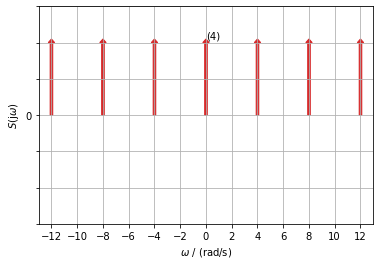

In [2]:
plt.figure(figsize=(6, 4))
ax = plt.axes()
for k in range(-12, 16, 4):
    ax.arrow(k, 0, 0, 1, head_width=0.5, head_length=0.05,
             fc='C3', ec='C3', width=0.2)
plt.text(0, 1.05, '(4)')
plt.yticks((0, 2))
plt.xticks(np.arange(-12, 16, 2))
plt.xlim(-13, 13)
plt.ylim(0, 1.2)
plt.yticks(np.arange(-1.5, 2, 0.5), ['', '', '', '0', '', '', ''])
plt.grid(True)
plt.xlabel(r'$\omega$ / (rad/s)')
plt.ylabel(r'$S(\mathrm{j} \omega)$')
plt.savefig('Sampling_01_DiracComb_EF235EE3D8.pdf')

## Sine Signal

The harmonic signal with $\omega_0=3$ rad/s

\begin{equation}
x(t) = \sin(\omega_0 t) = \sin(3 t)
\end{equation}

is to be sampled with the above introduced Dirac comb.

The Fourier transform

\begin{equation}
X(\mathrm{j} \omega) = \mathrm{j} \pi [ \delta(\omega+\omega_0) - \delta(\omega-\omega_0) ] = \mathrm{j} \pi [\delta(\omega+3) - \delta(\omega-3)]
\end{equation}

of $x(t)$ is depicted below.
Note that the spectrum exhibits an imaginary part only.

For convenience a red line is drawn between the two Dirac entries of the Fourier transform. This will help clarify the aliasing contributions in the spectrum of the sampled signal.

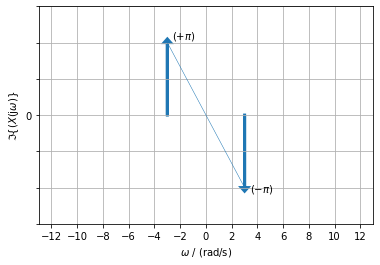

In [3]:
plt.figure(figsize=(6, 4))
ax = plt.axes()
ax.arrow(+3, 0, 0, -1, head_width=0.5,
         head_length=0.05, fc='C0', ec='C0', lw=3)
ax.arrow(-3, 0, 0, +1, head_width=0.5,
         head_length=0.05, fc='C0', ec='C0', lw=3)
plt.plot((-3, 3), (+1, -1), 'C0', lw=0.5)
plt.text(-2.6, 1.05, r'($+\pi$)')
plt.text(+3.4, -1.05, r'($-\pi$)')
plt.yticks((0, 2))
plt.xticks(np.arange(-12, 16, 2))
plt.xlim(-13, 13)
plt.ylim(-1.2, 1.2)
plt.yticks(np.arange(-1.5, 2, 0.5), ['', '', '', '0', '', '', ''])
plt.grid(True)
plt.xlabel(r'$\omega$ / (rad/s)')
plt.ylabel(r'$\Im\{(X(\mathrm{j} \omega)\}$')
plt.savefig('Sampling_02_Sine_EF235EE3D8.pdf')

## Sampling

The sampling process is modeled as

\begin{equation}
x_s(t) = x(t) \cdot h_s(t) \circ-\bullet X_s(\mathrm{j}\omega) = \frac{1}{2\pi} X(\mathrm{j}\omega) * H_s(\mathrm{j}\omega), 
\end{equation}

where the convolution with the Dirac comb in frequency domain is conveniently used to obtain the spectrum of $x_s(t)$. 

This Fourier transform is depicted below.

Note that the convolution is with respect of a pure real signal (Dirac comb) and a pure imaginary signal (sine) leading to a pure imaginary result.

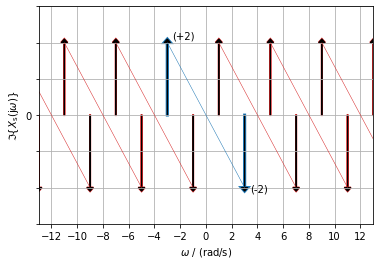

In [4]:
plt.figure(figsize=(6, 4))
ax = plt.axes()

for k in range(-5, 5):
    if k == 0:
        ax.arrow(+3+4*k, 0, 0, -1, head_width=0.5,
                 head_length=0.05, fc='C0', ec='C0', lw=3)
        ax.arrow(-3+4*k, 0, 0, +1, head_width=0.5,
                 head_length=0.05, fc='C0', ec='C0', lw=3)

        ax.arrow(+3+4*k, 0, 0, -1, head_width=0.5,
                 head_length=0.05, fc='k', ec='k', lw=1)
        ax.arrow(-3+4*k, 0, 0, +1, head_width=0.5,
                 head_length=0.05, fc='k', ec='k', lw=1)

        plt.plot((-3+4*k, 3+4*k), (+1, -1), 'C0', lw=0.5)
        plt.text(+3.4+4*k, -1.05, '(-2)')
        plt.text(-2.6+4*k, +1.05, '(+2)')
    else:
        ax.arrow(+3+4*k, 0, 0, -1, head_width=0.5,
                 head_length=0.05, fc='C3', ec='C3', lw=2)
        ax.arrow(-3+4*k, 0, 0, +1, head_width=0.5,
                 head_length=0.05, fc='C3', ec='C3', lw=2)
        ax.arrow(+3+4*k, 0, 0, -1, head_width=0.5,
                 head_length=0.05, fc='k', ec='k', lw=1)
        ax.arrow(-3+4*k, 0, 0, +1, head_width=0.5,
                 head_length=0.05, fc='k', ec='k', lw=1)
        plt.plot((-3+4*k, 3+4*k), (+1, -1), 'C3', lw=0.5)

plt.xticks(np.arange(-12, 16, 2))
plt.xlim(-13, 13)
plt.ylim(-1.2, 1.2)
plt.yticks(np.arange(-1.5, 2, 0.5), ['', '', '', '0', '', '', ''])
plt.grid(True)
plt.xlabel(r'$\omega$ / (rad/s)')
plt.ylabel(r'$\Im\{X_\mathrm{s}(\mathrm{j} \omega)\}$')
plt.savefig('Sampling_03_DiscreteSine_EF235EE3D8.pdf')

## Reconstruction

Reconstruction is modeled as

\begin{equation}
x_r(t) = x_s(t) * h_r(t) \circ-\bullet X_r(\mathrm{j}\omega) = X_s(\mathrm{j}\omega) \cdot H_r(\mathrm{j}\omega)
\end{equation}

with the spectrum of the ideal lowpass filter

\begin{equation}
H_r(\mathrm{j}\omega) = \frac{\pi}{2}\mathrm{rect}(\frac{\omega}{4}) \bullet - \circ h_r(t) = \mathrm{sinc}(2 t)
\end{equation}

is depicted below.

The cut frequency is $|\omega_c| = 2$ rad/s.


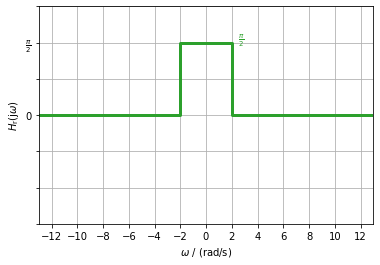

In [5]:
plt.figure(figsize=(6, 4))
ax = plt.axes()
plt.plot((-13, -2, -2, +2, +2, +13), (0, 0, 1, 1, 0, 0), 'C2', lw=3)
plt.xticks(np.arange(-12, 16, 2))
plt.xlim(-13, 13)
plt.ylim(-1.2, 1.2)
plt.yticks(np.arange(-1.5, 2, 0.5),
           ['', '', '', '0', '', r'$\frac{\pi}{2}$', ''])
plt.text(2.5, 1, r'$\frac{\pi}{2}$', color='C2')
plt.grid(True)
plt.xlabel(r'$\omega$ / (rad/s)')
plt.ylabel(r'$H_\mathrm{r}(\mathrm{j} \omega)$')
plt.savefig('Sampling_04_LowpassSpectrum_EF235EE3D8.pdf')

The sinc-shaped, infinite (and thus not feasible) impulse response of the ideal lowpass filter is depicted below.

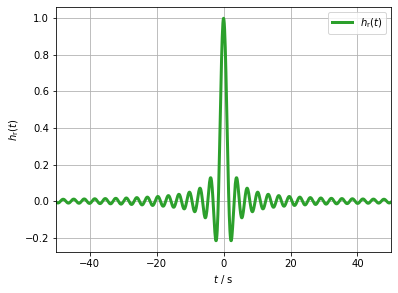

In [6]:
plt.figure(figsize=(6, 4.5))
t = np.arange(-50, +50, 0.1)
hr = my_sinc(2*t)
plt.plot(t, hr, 'C2', lw=3, label=r'$h_\mathrm{r}(t)$')
plt.xlabel(r'$t$ / s')
plt.xlim(-50, +50)
plt.ylabel(r'$h_\mathrm{r}(t)$')
plt.legend()
plt.grid(True)
plt.savefig('Sampling_05_LowpassIR_EF235EE3D8.pdf')

We can include the spectrum $H_r(\mathrm{j} \omega)$ with proportionally correct amplitude into the graphics of $X_s(\mathrm{j} \omega)$.

This is shown in the next plot.

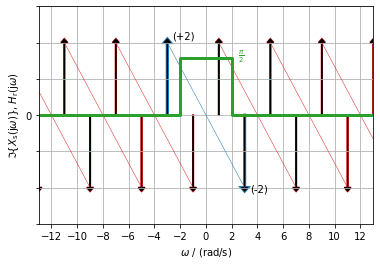

In [7]:
plt.figure(figsize=(6, 4))
ax = plt.axes()
for k in range(-5, 5):
    if k == 0:
        ax.arrow(+3+4*k, 0, 0, -1, head_width=0.5,
                 head_length=0.05, fc='C0', ec='C0', lw=3)
        ax.arrow(-3+4*k, 0, 0, +1, head_width=0.5,
                 head_length=0.05, fc='C0', ec='C0', lw=3)
        ax.arrow(+3+4*k, 0, 0, -1, head_width=0.5,
                 head_length=0.05, fc='k', ec='k', lw=1)
        ax.arrow(-3+4*k, 0, 0, +1, head_width=0.5,
                 head_length=0.05, fc='k', ec='k', lw=1)
        plt.plot((-3+4*k, 3+4*k), (+1, -1), 'C0', lw=0.5)
        plt.text(+3.4+4*k, -1.05, '(-2)')
        plt.text(-2.6+4*k, +1.05, '(+2)')
    else:
        ax.arrow(+3+4*k, 0, 0, -1, head_width=0.5,
                 head_length=0.05, fc='C3', ec='C3', lw=2)
        ax.arrow(-3+4*k, 0, 0, +1, head_width=0.5,
                 head_length=0.05, fc='C3', ec='C3', lw=2)
        ax.arrow(+3+4*k, 0, 0, -1, head_width=0.5,
                 head_length=0.05, fc='k', ec='k', lw=1)
        ax.arrow(-3+4*k, 0, 0, +1, head_width=0.5,
                 head_length=0.05, fc='k', ec='k', lw=1)
        plt.plot((-3+4*k, 3+4*k), (+1, -1), 'C3', lw=0.5)

plt.text(2.5, 1/2*np.pi/2, r'$\frac{\pi}{2}$', color='C2')
plt.plot((-13, -2, -2, +2, +2, +13), (0, 0, 1/2 *
         np.pi/2, 1/2*np.pi/2, 0, 0), 'C2', lw=3)
plt.xticks(np.arange(-12, 16, 2))
plt.xlim(-13, 13)
plt.ylim(-1.2, 1.2)
plt.yticks(np.arange(-1.5, 2, 0.5), ['', '', '', '0', '', '', ''])
plt.grid(True)
plt.xlabel(r'$\omega$ / (rad/s)')
plt.ylabel(
    r'$\Im\{X_\mathrm{s}(\mathrm{j} \omega)\}$, $H_\mathrm{r}(\mathrm{j} \omega)$')
plt.savefig('Sampling_06_DiscreteSineLowpassSpectrum_EF235EE3D8.pdf')

The filter cancels all contributions for $|\omega|>2$ rad/s and leaves exactly two Dirac impulses at $\omega = \pm 1$ rad/s.
These contributions are aliasing contributions mirrored into the passband of the reconstruction filter.
The resulting spectrum $X_r(\mathrm{j} \omega)$ is depicted below.

Note that the result remains purely imaginary, since the lowpass spectrum is purely real.

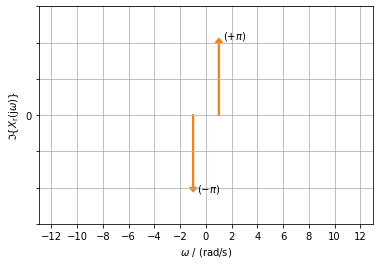

In [8]:
plt.figure(figsize=(6, 4))
ax = plt.axes()
ax.arrow(-1, 0, 0, -1, head_width=0.5,
         head_length=0.05, fc='C1', ec='C1', lw=2)
ax.arrow(+1, 0, 0, +1, head_width=0.5,
         head_length=0.05, fc='C1', ec='C1', lw=2)
plt.text(1.3, 1.05, r'($+\pi$)')
plt.text(-0.7, -1.05, r'($-\pi$)')
plt.yticks((0, 2))
plt.xticks(np.arange(-12, 16, 2))
plt.xlim(-13, 13)
plt.ylim(-1.2, 1.2)
plt.yticks(np.arange(-1.5, 2, 0.5), ['', '', '', '0', '', '', ''])
plt.grid(True)
plt.xlabel(r'$\omega$ / (rad/s)')
plt.ylabel(r'$\Im\{X_\mathrm{r}(\mathrm{j} \omega)\}$')
plt.savefig('Sampling_07_ReconstructedSine_EF235EE3D8.pdf')

* 2.) 

The signal that is been reconstructed can be directly evaluated from the simple spectrum $X_r(\mathrm{j} \omega)$.
One might recognize, that these two diracs correspond to a sine function

\begin{equation}
x_r(t) = - \sin(1\cdot t) \circ-\bullet X_r(\mathrm{j} \omega) = -\mathrm{j} \pi [\delta(\omega+1) - \delta(\omega-1)] 
\end{equation}

i.e. a sine with $\omega_{0,s} = 1$ rad/s (instead original $\omega_{0} = 3$ rad/s) and inverted polarity (instead of non-inverted original).

* 3.)

As seen in 2.) reconstruction was not successful, due to undersampling of the signal $x(t)$.

For correct reconstruction two conditions must be achieved:

* smaller sampling intervall, $T\leq\frac{\pi}{3}$, i.e. larger sampling frequency $\omega_s\geq 6$ rad/s. So called critical/Nyquist sampling is realized if $T=\frac{\pi}{3}$ and thus $\omega_s=\frac{2 \pi}{\frac{\pi}{3}}= 6$ rad/s.

* larger bandwidth of the lowpass filter, such that the passband includes $\omega_0$, but no aliasing contributions.For critical sampling with $\omega_s = 6$ rad/s the required cut frequency $\omega_c = 3$ rad/s for the ideal lowpass filter leads to
\begin{equation}
H_r(\mathrm{j}\omega) = \frac{\pi}{3}\mathrm{rect}(\frac{\omega}{6}) \bullet - \circ h_r(t) = \mathrm{sinc}(3 t).
\end{equation}

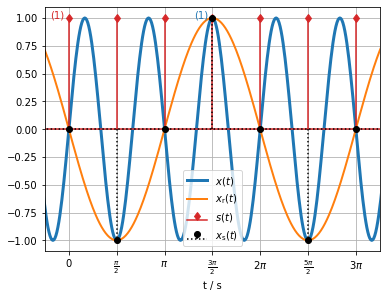

In [9]:
plt.figure(figsize=(6, 4.5))
t = np.arange(-np.pi, 4*np.pi, (2*np.pi/3)/2**6)

x = np.sin(3*t)
plt.plot(t, x, 'C0', label=r'$x(t)$', lw=3)
xr = -np.sin(1*t)
plt.plot(t, xr, 'C1', label=r'$x_\mathrm{r}(t)$', lw=2)

td = np.arange(-np.pi, 4*np.pi+np.pi/2, np.pi/2)

s = td*0 + 1
plt.stem(td, s,
         use_line_collection=True,
         linefmt='C3',
         markerfmt='C3d',
         basefmt='C3', label=r'$s(t)$')
xs = np.sin(3*td)
plt.stem(td, xs,
         use_line_collection=True,
         linefmt='k:',
         markerfmt='ko',
         basefmt='k:', label=r'$x_\mathrm{s}(t)$')

plt.xticks(np.arange(0, 4*np.pi, np.pi/2),
           ['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$', r'$\frac{5\pi}{2}$', r'$3 \pi$', r'$\frac{7\pi}{2}$'])

plt.text(-0.6, 1, '(1)', color='C3')
plt.text(-0.6+3/2*np.pi, 1, '(1)', color='C0')

plt.xlim(-np.pi/4, 3*np.pi+np.pi/4)
plt.xlabel('t / s')
plt.legend(loc='lower center')
plt.grid(True)
plt.savefig('TimeSignals_EF235EE3D8.pdf')

In [10]:
def sine_sampling_sinc_interpolation():
    t = np.arange(-np.pi, 4*np.pi, (2*np.pi/3)/2**6)

    x = np.sin(w0*t)
    xr = np.zeros_like(x)

    plt.figure(figsize=(6, 4.5))

    M = 200
    for m in range(-M, +M+1):
        td = (m*Ts)
        xm = np.sin(w0*td) * my_sinc(wc*(t-td))
        plt.plot(t, xm, 'C7', lw=0.5)
        xr += xm
    plt.plot(t, xr, 'C1', lw=3, label=r'$\approx x_\mathrm{r}(t)$')

    for m in range(1, 6):
        td = (m*Ts)
        xm = np.sin(w0*td) * my_sinc(wc*(t-td))
        plt.plot(t, xm, color='C'+str(m+1), lw=2, label=r'$m=%d$' % m)

    plt.xticks(np.arange(0, 4*np.pi, np.pi/2),
               ['0', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$', r'$\frac{5\pi}{2}$', r'$3 \pi$', r'$\frac{7\pi}{2}$'])
    plt.xlim(-np.pi/4, 3*np.pi+np.pi/4)
    plt.xlabel('t / s')

    plt.title(r'$x(t)=sin(\omega_0 t)$, $\omega_0=$%2.1f rad/s, $T_s=\pi/$%2.1f s, $\omega_s=$%2.1f rad/s, $\omega_c$=%2.1f rad/s' %
              (w0, np.pi/Ts, ws, wc))

    plt.plot(t, x, 'C0', lw=1, label=r'$x(t)$')

    plt.legend()
    plt.grid(True)

    print(w0, Ts, ws, wc)

3 1.5707963267948966 4.0 2


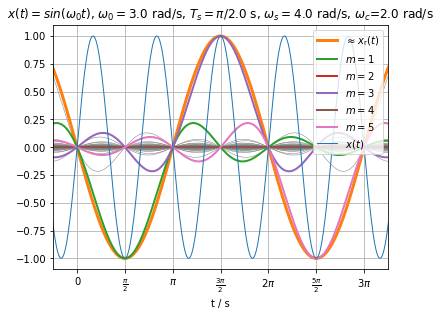

In [11]:
Ts = np.pi/2
ws = 2*np.pi/Ts
wc = 2
w0 = 3
sine_sampling_sinc_interpolation()
plt.savefig('SincInterpolation_Aliasing_EF235EE3D8.pdf')

3 0.7853981633974483 8 4.0


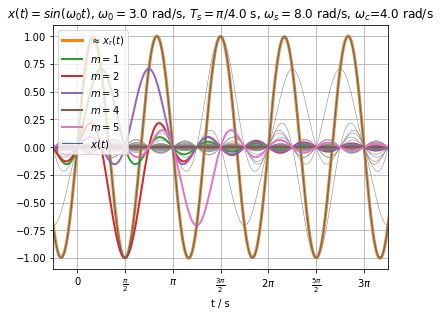

In [12]:
w0 = 3
ws = 8
wc = ws/2
Ts = 2*np.pi/ws
sine_sampling_sinc_interpolation()
plt.savefig('SincInterpolation_NoAliasing_EF235EE3D8.pdf')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.